In [1]:
import os
import ast
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

<jemalloc>: Unsupported system page size


In [2]:
import pandas as pd
import os

# Base path
path = "/datasets/multi-view-pig-posture-recognition"
train2_path = f"{path}/train2.csv"
train2_images_path = f"{path}/train2_images"
test_path = f"{path}/test.csv"
test_images_path = f"{path}/test_images"
sample_submission_path = f"{path}/sample_submission.csv"
txt_path = f"{path}/pig_posture_classes.txt"

# Load CSVs
train_df = pd.read_csv(train2_path)
test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

# Load class labels
with open(txt_path, "r") as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")
print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")
train_df.head()

Classes: ['Lateral_lying_left', 'Lateral_lying_right', 'Sitting', 'Standing', 'Sternal_lying']
Train samples: 23450, Test samples: 11708


,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [3]:
TRAIN_IMG_DIR = train2_images_path
TEST_IMG_DIR = test_images_path

In [4]:
print("Unique train images: ", train_df["image_id"].nunique())
print("Unique test images: ", test_df["image_id"].nunique())

print("Train instances: ", len(train_df))
print("Test instances: ", len(test_df))

Unique train images:  3150
Unique test images:  1350
Train instances:  23450
Test instances:  11708


class_id
0    3083
1    3435
2     695
3    9928
4    6309
Name: count, dtype: int64


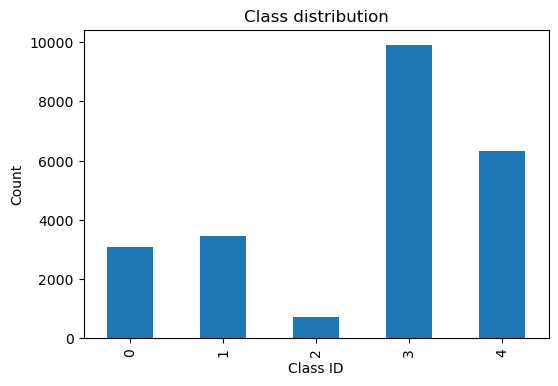

In [5]:
#Class distribution

class_counts = train_df["class_id"].value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [6]:
#Bounding box analysis

def parse_bbox(bbox_str):
    return ast.literal_eval(bbox_str)

train_df["parsed_bbox"] = train_df["bbox"].apply(parse_bbox)

train_df[["xmin", "ymin", "w", "h"]] = pd.DataFrame(
    train_df["parsed_bbox"].tolist(),
    index = train_df.index
)

train_df["area"] = train_df["w"] * train_df["h"]

print("BBox Width stats:")
print(train_df['w'].describe())

print("\nBBox height stats:")
print(train_df["h"].describe())

print("\nBBox area stats:")
print(train_df["area"].describe())

BBox Width stats:
count    23450.000000
mean       300.014670
std        147.973854
min         44.400000
25%        187.000000
50%        281.000000
75%        383.000000
max       1120.000000
Name: w, dtype: float64

BBox height stats:
count    23450.000000
mean       295.973906
std        141.796523
min         75.000000
25%        188.925000
50%        258.150000
75%        395.000000
max       1164.000000
Name: h, dtype: float64

BBox area stats:
count     23450.000000
mean      95399.564287
std       82868.543783
min        6900.320000
25%       45640.402500
50%       70118.500000
75%      110339.500000
max      763617.000000
Name: area, dtype: float64


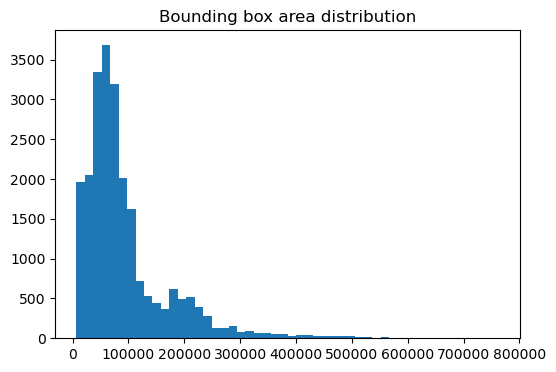

In [7]:
#BBox size distribution

plt.figure(figsize=(6,4))
plt.hist(train_df["area"], bins=50)
plt.title("Bounding box area distribution")
plt.show()

Mean pig per image:  7.444444444444445
Max pig in one image:  11


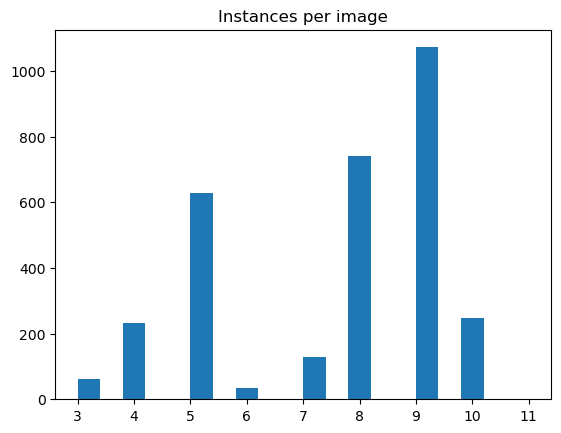

In [8]:
#Instances per images

instances_per_image = train_df.groupby("image_id").size()

print("Mean pig per image: ", instances_per_image.mean())
print("Max pig in one image: ", instances_per_image.max())

plt.hist(instances_per_image, bins=20)
plt.title("Instances per image")
plt.show()

In [9]:
#Image resolution check

image_size = []

for img_name in tqdm(train_df["image_id"].unique()):
    img_path = os.path.join(TRAIN_IMG_DIR, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        image_size.append((w, h))

image_size = pd.DataFrame(
    image_size,
    columns = ["width", "height"]
)

print("Image size:\n ",image_size.describe())

100%|██████████| 3150/3150 [01:06<00:00, 47.41it/s]

Image size:
               width       height
count  3150.000000  3150.000000
mean   1611.946667   907.225397
std     413.067697   233.671967
min    1280.000000   720.000000
25%    1280.000000   720.000000
50%    1280.000000   720.000000
75%    1920.000000  1080.000000
max    2688.000000  1520.000000


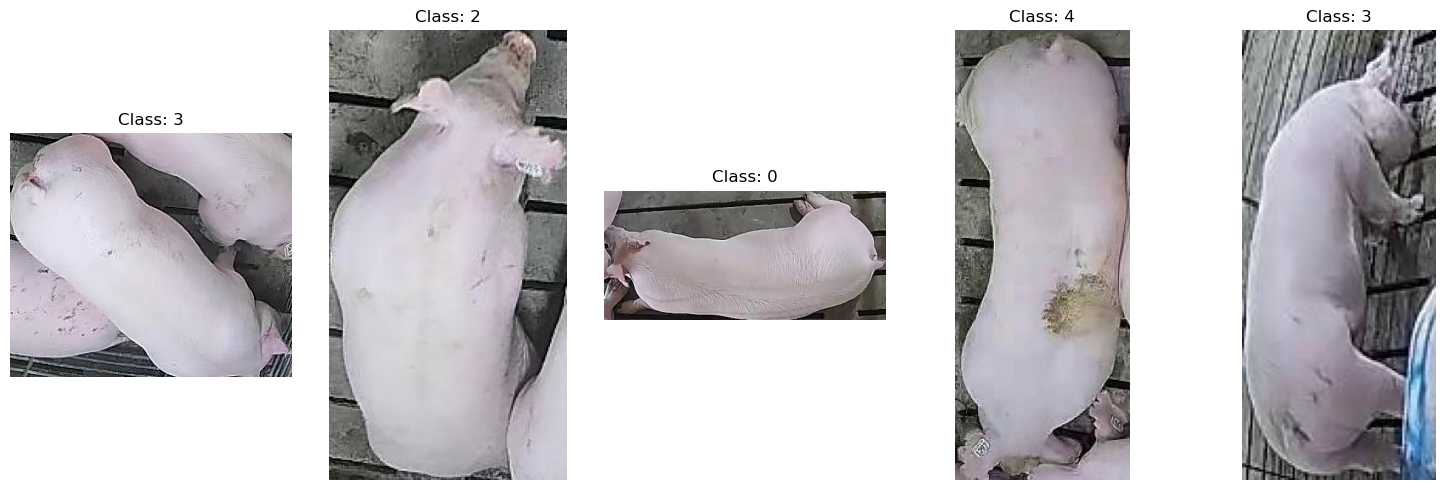

In [10]:
#Cropped instances

def show_random_samples(df, num_samples=5):
    samples = df.sample(num_samples)

    plt.figure(figsize=(15, 5))

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(TRAIN_IMG_DIR, row["image_id"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        xmin, ymin, w, h = row["xmin"], row["ymin"], row["w"], row["h"]
        crop = img[int(ymin):int(ymin+h), int(xmin):int(xmin+w)]

        plt.subplot(1, num_samples, i+1)
        plt.imshow(crop)
        plt.title(f"Class: {row['class_id']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(train_df, 5)

In [11]:
#!pip install timm -q

In [12]:
import os
import ast
import cv2
import numpy as np
import pandas as pd
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm

In [13]:
class CFG:
    IMG_SIZE = 300
    BATCH_SIZE = 16
    EPOCHS = 5
    LR = 3e-4
    NUM_CLASSES = 5
    DEVICE = "cuda:3"
    SEED = 42
    N_FOLDS = 5

In [14]:
#Seed Everything

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.SEED)

In [15]:
import os

# Base dataset path
BASE_DIR = "/datasets/multi-view-pig-posture-recognition"

# File paths
TRAIN_CSV = os.path.join(BASE_DIR, "train2.csv")
TEST_CSV = os.path.join(BASE_DIR, "test.csv")
SAMPLE_SUB_CSV = os.path.join(BASE_DIR, "sample_submission.csv")
CLASS_TXT = os.path.join(BASE_DIR, "pig_posture_classes.txt")

# Image directories
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train2_images")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")

# Verify paths exist
for p in [TRAIN_CSV, TEST_CSV, SAMPLE_SUB_CSV, CLASS_TXT, TRAIN_IMG_DIR, TEST_IMG_DIR]:
    exists = "✓" if os.path.exists(p) else "✗ MISSING"
    print(f"  {exists}  {p}")

import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SAMPLE_SUB_CSV)

with open(CLASS_TXT, "r") as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")
print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")
train_df.head()

  ✓  /datasets/multi-view-pig-posture-recognition/train2.csv
  ✓  /datasets/multi-view-pig-posture-recognition/test.csv
  ✓  /datasets/multi-view-pig-posture-recognition/sample_submission.csv
  ✓  /datasets/multi-view-pig-posture-recognition/pig_posture_classes.txt
  ✓  /datasets/multi-view-pig-posture-recognition/train2_images
  ✓  /datasets/multi-view-pig-posture-recognition/test_images
Classes: ['Lateral_lying_left', 'Lateral_lying_right', 'Sitting', 'Standing', 'Sternal_lying']
Train samples: 23450, Test samples: 11708


,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [16]:
#Albumentations

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.5),
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

In [17]:
import ast

import ast
from PIL import Image

import ast
import numpy as np

class PigDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        bbox = row["bbox"]
        if isinstance(bbox, str):
            bbox = ast.literal_eval(bbox)
        xmin, ymin, w, h = [int(v) for v in bbox]

        crop = img[ymin:ymin+h, xmin:xmin+w]

        if self.transform:
            crop = self.transform(image=crop)["image"]

        label = int(row["class_id"])
        return crop, label

In [18]:
#Model

class PigModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained = True,
            num_classes = 0
        )
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1536, CFG.NUM_CLASSES)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [19]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)

        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            ce_loss = ce_loss * at

        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()
        

In [20]:
#Class Weights

class_counts = train_df["class_id"].value_counts().sort_index()
weights = len(train_df) / (CFG.NUM_CLASSES * class_counts)
weights = torch.tensor(weights.values, dtype=torch.float).to(CFG.DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)

In [22]:
#training loop
print(train_df.columns.tolist())
print(train_df.head(2))


#Train + validation split (5 Fold training)

skf = StratifiedGroupKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)

CFG.DEVICE = "cuda:3"

fold_models = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df, train_df["class_id"], groups=train_df["image_id"])
):
    print(f"\n===============FOLD {fold+1}=======================")
    

    train_dataset = PigDataset(train_df.iloc[train_idx],
                              TRAIN_IMG_DIR,
                              train_transform)
    
    val_dataset = PigDataset(train_df.iloc[val_idx],
                            TRAIN_IMG_DIR,
                            valid_transform)
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=CFG.BATCH_SIZE, 
        shuffle= True,
        num_workers = 4
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size = CFG.BATCH_SIZE,
        shuffle = False,
        num_workers = 4
    )
    
    model = PigModel().to(CFG.DEVICE)
    
    optimizer = optim.AdamW(model.parameters(), lr=CFG.LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max = CFG.EPOCHS
    )
    
    scaler = torch.cuda.amp.GradScaler()
    
    best_f1 = 0
    
    for epoch in range(CFG.EPOCHS):
        model.train()
    
        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
    
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
    
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()
    
        #Validation
        model.eval()
        val_preds, val_true = [], []
    
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader):
                imgs = imgs.to(CFG.DEVICE)
                labels = labels.to(CFG.DEVICE)
                
                outputs = model(imgs)
                batch_preds = torch.argmax(outputs, dim=1).cpu().numpy()
    
                val_preds.extend(batch_preds)
                val_true.extend(labels.cpu().numpy())
    
        f1 = f1_score(val_true, val_preds, average="macro")
        print(f"Epoch {epoch+1} | F1: {f1:.4f}")
    
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), f"model_fold{fold}.pth")
    
    fold_models.append(f"model_fold{fold}.pth")

['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   
1  train_pen1_orb_cam1_20250108_085204_0001   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
1  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  
1  [1278.5,428.0,233.0,438.0]         4  

===============FOLD 1=======================


100%|██████████| 293/293 [00:30<00:00,  9.51it/s]


Epoch 1 | F1: 0.7633


100%|██████████| 293/293 [00:28<00:00, 10.37it/s]


Epoch 2 | F1: 0.8387


...

Epoch 3 | F1: 0.8913


100%|██████████| 297/297 [00:29<00:00, 10.02it/s]


Epoch 4 | F1: 0.9118


100%|██████████| 297/297 [00:29<00:00, 10.08it/s]

Epoch 5 | F1: 0.9232


In [26]:
# --- 1. Patch PigDataset to support test mode ---

class PigDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Parse bbox
        bbox = row["bbox"]
        if isinstance(bbox, str):
            bbox = list(map(float, bbox.strip("[]").split(",")))
        xmin, ymin, w, h = [int(v) for v in bbox]

        # Clip to image boundaries
        H, W = img.shape[:2]
        x1 = max(0, xmin)
        y1 = max(0, ymin)
        x2 = min(W, xmin + w)
        y2 = min(H, ymin + h)
        crop = img[y1:y2, x1:x2]

        if crop.size == 0:
            crop = img  # fallback to full image

        if self.transform:
            crop = self.transform(image=crop)["image"]

        if self.is_test:
            return crop

        label = int(row["class_id"])
        return crop, label


# --- 2. Build test dataset & loader ---

test_dataset = PigDataset(
    test_df,
    os.path.join(BASE_DIR, "test_images"),  # fixed: BASE_DIR not BASE_PATH
    valid_transform,
    is_test=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# --- 3. Collect saved model paths (adjust glob pattern to your naming) ---

import glob
fold_models = sorted(glob.glob("model_fold*.pth"))
print(f"Found {len(fold_models)} fold models: {fold_models}")

# --- 4. Fold-wise inference with TTA ---

all_fold_preds = []

for fold_path in fold_models:
    model = PigModel().to(CFG.DEVICE)
    model.load_state_dict(torch.load(f"model_fold{fold}.pth", map_location=CFG.DEVICE))
    model.eval()

    fold_probs = []

    with torch.no_grad():
        for imgs in tqdm(test_loader):
            imgs = imgs.to(CFG.DEVICE)

            # Normal forward
            probs1 = torch.softmax(model(imgs), dim=1)

            # TTA: horizontal flip
            probs2 = torch.softmax(model(torch.flip(imgs, dims=[3])), dim=1)

            prob = (probs1 + probs2) / 2
            fold_probs.append(prob.cpu().numpy())

    fold_probs = np.concatenate(fold_probs)
    all_fold_preds.append(fold_probs)

# --- 5. Ensemble across folds & build submission ---

final_probs = np.mean(all_fold_preds, axis=0)
final_preds = np.argmax(final_probs, axis=1)

test_df["class_id"] = final_preds
print(test_df["class_id"].value_counts())

Found 5 fold models: ['model_fold0.pth', 'model_fold1.pth', 'model_fold2.pth', 'model_fold3.pth', 'model_fold4.pth']


100%|██████████| 732/732 [01:26<00:00,  8.43it/s]

class_id
3    5923
4    2658
0    1572
1     900
2     655
Name: count, dtype: int64


In [27]:
#Submission

submission = pd.DataFrame({
    "row_id" : test_df["row_id"],
    "class_id" : final_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

,row_id,class_id
0,test_pen1_tur_cam1_20250920_174649_0000,3
1,test_pen1_tur_cam1_20250920_174649_0001,0
2,test_pen1_tur_cam1_20250920_174649_0002,0
3,test_pen1_tur_cam1_20250920_174649_0003,1
4,test_pen1_tur_cam1_20250920_174649_0004,1


/tmp/ipykernel_1086/2322796483.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(confidence_per_class, labels=[str(c) for c in range(CFG.NUM_CLASSES)], patch_artist=True)


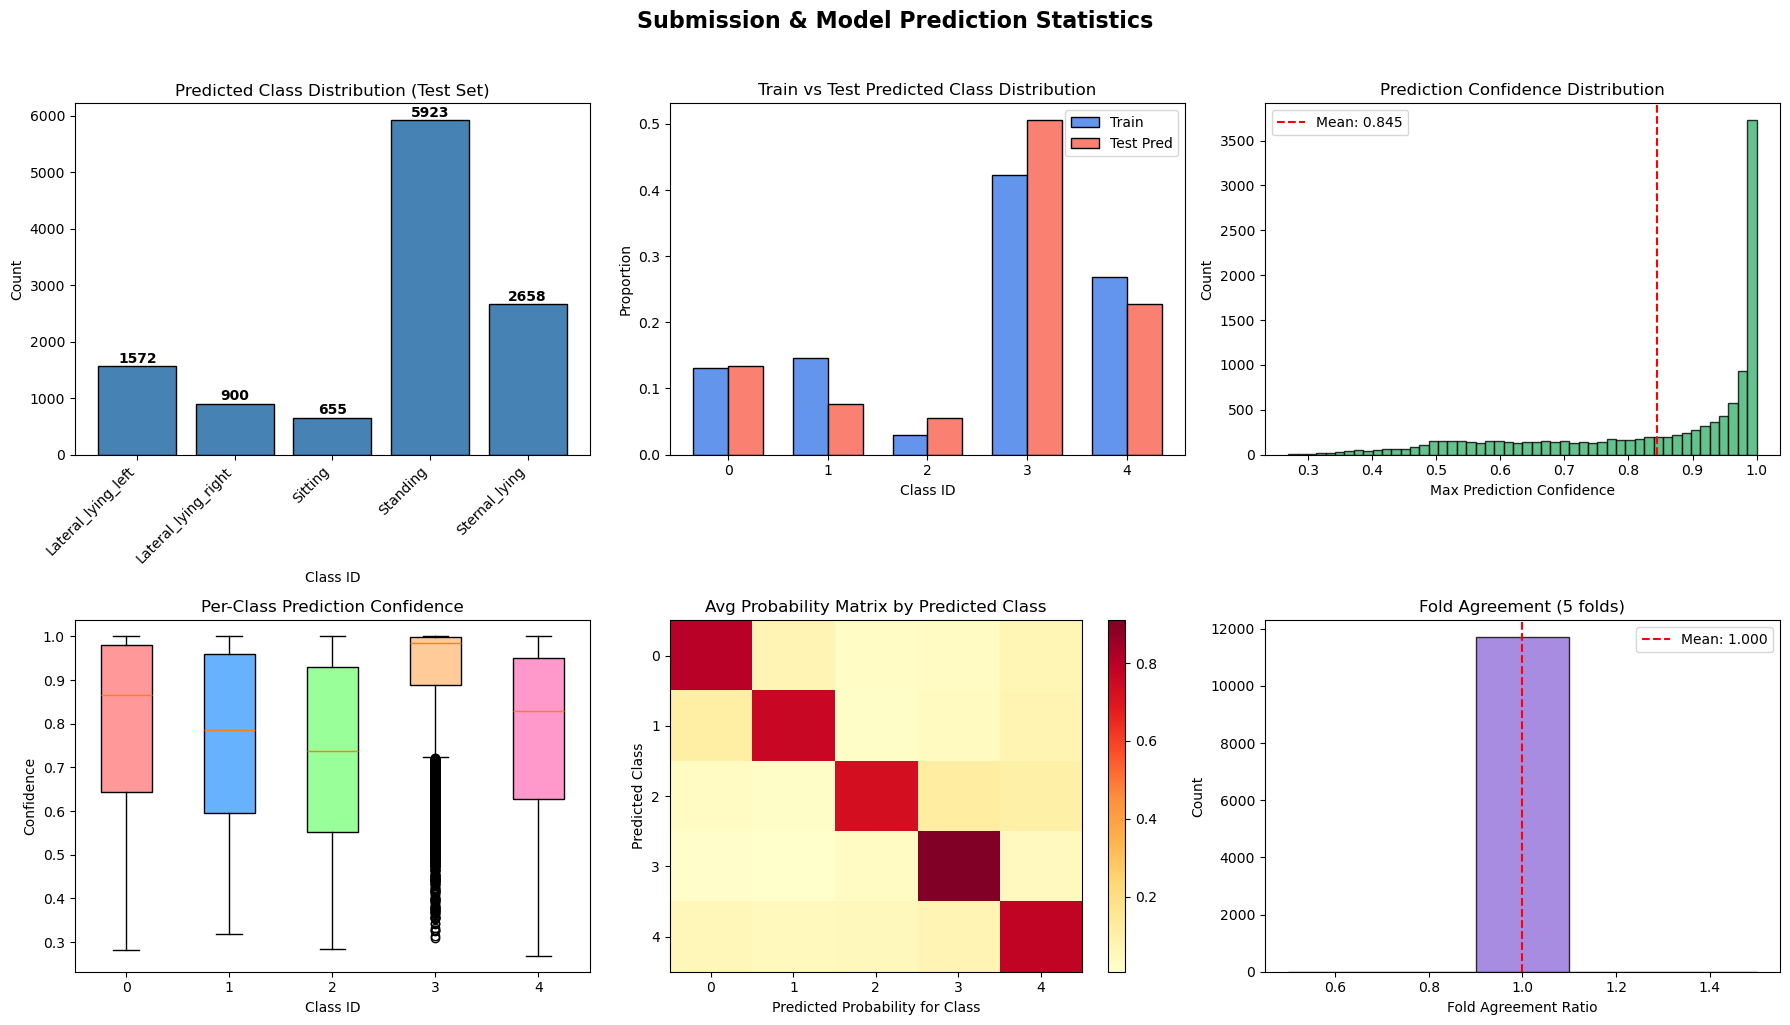


Total test samples: 11708
Mean confidence: 0.8447
Median confidence: 0.9344
Low confidence samples (<0.5): 741
High confidence samples (>0.9): 6583
Mean fold agreement: 1.0000


In [28]:
#plot statistics of predictions and model# --- Plot Statistics of Predictions ---

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Class distribution in predictions
ax = axes[0, 0]
class_counts_pred = submission["class_id"].value_counts().sort_index()
bars = ax.bar(class_counts_pred.index, class_counts_pred.values, color='steelblue', edgecolor='black')
ax.set_xlabel("Class ID")
ax.set_ylabel("Count")
ax.set_title("Predicted Class Distribution (Test Set)")
ax.set_xticks(range(CFG.NUM_CLASSES))
if len(classes) == CFG.NUM_CLASSES:
    ax.set_xticklabels(classes, rotation=45, ha='right')
for bar, count in zip(bars, class_counts_pred.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Train vs Test class distribution comparison
ax = axes[0, 1]
train_class_dist = train_df["class_id"].value_counts(normalize=True).sort_index()
test_class_dist = submission["class_id"].value_counts(normalize=True).sort_index()
x = np.arange(CFG.NUM_CLASSES)
width = 0.35
ax.bar(x - width/2, train_class_dist.reindex(range(CFG.NUM_CLASSES), fill_value=0).values, width, label='Train', color='cornflowerblue', edgecolor='black')
ax.bar(x + width/2, test_class_dist.reindex(range(CFG.NUM_CLASSES), fill_value=0).values, width, label='Test Pred', color='salmon', edgecolor='black')
ax.set_xlabel("Class ID")
ax.set_ylabel("Proportion")
ax.set_title("Train vs Test Predicted Class Distribution")
ax.set_xticks(x)
ax.legend()

# 3. Confidence distribution (max probability)
ax = axes[0, 2]
max_confidences = np.max(final_probs, axis=1)
ax.hist(max_confidences, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax.set_xlabel("Max Prediction Confidence")
ax.set_ylabel("Count")
ax.set_title("Prediction Confidence Distribution")
ax.axvline(np.mean(max_confidences), color='red', linestyle='--', label=f'Mean: {np.mean(max_confidences):.3f}')
ax.legend()

# 4. Per-class confidence boxplot
ax = axes[1, 0]
confidence_per_class = [max_confidences[final_preds == c] for c in range(CFG.NUM_CLASSES)]
bp = ax.boxplot(confidence_per_class, labels=[str(c) for c in range(CFG.NUM_CLASSES)], patch_artist=True)
colors_bp = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for patch, color in zip(bp['boxes'], colors_bp[:CFG.NUM_CLASSES]):
    patch.set_facecolor(color)
ax.set_xlabel("Class ID")
ax.set_ylabel("Confidence")
ax.set_title("Per-Class Prediction Confidence")

# 5. Probability heatmap (average per class)
ax = axes[1, 1]
avg_probs_per_class = np.zeros((CFG.NUM_CLASSES, CFG.NUM_CLASSES))
for c in range(CFG.NUM_CLASSES):
    mask = final_preds == c
    if mask.sum() > 0:
        avg_probs_per_class[c] = final_probs[mask].mean(axis=0)
im = ax.imshow(avg_probs_per_class, cmap='YlOrRd', aspect='auto')
ax.set_xlabel("Predicted Probability for Class")
ax.set_ylabel("Predicted Class")
ax.set_title("Avg Probability Matrix by Predicted Class")
ax.set_xticks(range(CFG.NUM_CLASSES))
ax.set_yticks(range(CFG.NUM_CLASSES))
plt.colorbar(im, ax=ax)

# 6. Fold-wise prediction agreement
ax = axes[1, 2]
fold_preds_argmax = [np.argmax(fp, axis=1) for fp in all_fold_preds]
agreement = np.zeros(len(final_preds))
for i in range(len(final_preds)):
    preds_i = [fp[i] for fp in fold_preds_argmax]
    agreement[i] = preds_i.count(max(set(preds_i), key=preds_i.count)) / len(preds_i)
ax.hist(agreement, bins=len(fold_models), color='mediumpurple', edgecolor='black', alpha=0.8)
ax.set_xlabel("Fold Agreement Ratio")
ax.set_ylabel("Count")
ax.set_title(f"Fold Agreement ({len(fold_models)} folds)")
ax.axvline(np.mean(agreement), color='red', linestyle='--', label=f'Mean: {np.mean(agreement):.3f}')
ax.legend()

plt.suptitle("Submission & Model Prediction Statistics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("prediction_statistics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"Total test samples: {len(submission)}")
print(f"Mean confidence: {max_confidences.mean():.4f}")
print(f"Median confidence: {np.median(max_confidences):.4f}")
print(f"Low confidence samples (<0.5): {(max_confidences < 0.5).sum()}")
print(f"High confidence samples (>0.9): {(max_confidences > 0.9).sum()}")
print(f"Mean fold agreement: {np.mean(agreement):.4f}")
print(f"{'='*50}")
